## Install nesserary liberaries

In [1]:
!pip install imagehash ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.8 MB/s eta 0:00:00a 0:00:01


In [2]:
! pip install torch torchvision

In [3]:
!pip install kagglehub
!pip install kaggle
!pip install tensorflow

In [4]:
!pip install torchvision torch

In [5]:
!pip install fastapi uvicorn tensorflow pillow

# Import libs

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import os
import random
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import imagehash
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing import image
import torch
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models
from torchvision.transforms import functional as TF
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from ultralytics import YOLO

2026-05-21 07:16:43.833831: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779347804.025358      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779347804.082360      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779347804.526427      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779347804.526470      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779347804.526474      57 computation_placer.cc:177] computation placer alr

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## doownloud ds

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salmansajid05/oral-diseases")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/salmansajid05/oral-diseases


## Helper function

In [8]:
def copy_dataset(source_path, dest_path, class_name):
	source_path = Path(source_path)
	dest_path = Path(dest_path)

	if source_path.exists():
		try:
			shutil.copytree(source_path, dest_path)
			print(f"✓ {class_name} copied successfully")
		except Exception as e:
			print(f"✗ Error copying {class_name}: {e}")
	else:
		print(f"✗ Source path not found for {class_name}: {source_path}")

# Caries
caries_file_path = Path(path) / 'Data caries' / 'Data caries' / 'caries augmented data set' / 'preview'
caries_new_directory = Path('/kaggle/working/oral-diseases/caries')
copy_dataset(caries_file_path, caries_new_directory, "Caries")

# Calculus
calculus_file_path = Path(path) / 'Calculus' / 'Calculus'
calculus_new_directory = Path('/kaggle/working/oral-diseases/calculus')
copy_dataset(calculus_file_path, calculus_new_directory, "Calculus")

# Gingivitis
gingivitis_file_path = Path(path) / 'Gingivitis' / 'Gingivitis'
gingivitis_new_directory = Path('/kaggle/working/oral-diseases/gingivitis')
copy_dataset(gingivitis_file_path, gingivitis_new_directory, "Gingivitis")

# Ulcers
ulcer_file_path = Path(path) / 'Mouth Ulcer' / 'Mouth Ulcer' / 'Mouth_Ulcer_augmented_DataSet' / 'preview'
ulcer_new_directory = Path('/kaggle/working/oral-diseases/ulcers')
copy_dataset(ulcer_file_path, ulcer_new_directory, "Ulcers")

# Tooth Discoloration (remove trailing space from the path)
toothDiscoloration_file_path = Path(path) / 'Tooth Discoloration' / 'Tooth Discoloration '
toothDiscoloration_new_directory = Path('/kaggle/working/oral-diseases/toothDiscoloration')
copy_dataset(toothDiscoloration_file_path, toothDiscoloration_new_directory, "Tooth Discoloration")

# Hypodontia
hypodontia_file_path = Path(path) / 'hypodontia' / 'hypodontia'
hypodontia_new_directory = Path('/kaggle/working/oral-diseases/hypodontia')
copy_dataset(hypodontia_file_path, hypodontia_new_directory, "Hypodontia")

✓ Caries copied successfully
✓ Calculus copied successfully
✓ Gingivitis copied successfully
✓ Ulcers copied successfully
✓ Tooth Discoloration copied successfully
✓ Hypodontia copied successfully


In [9]:
img_train   = '/kaggle/input/datasets/salmansajid05/oral-diseases/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Data/images/train'
label_train = '/kaggle/input/datasets/salmansajid05/oral-diseases/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Data/labels/train'
img_val     = '/kaggle/input/datasets/salmansajid05/oral-diseases/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Data/images/val'
label_val   = '/kaggle/input/datasets/salmansajid05/oral-diseases/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Data/labels/val'
annotation  = '/kaggle/input/datasets/salmansajid05/oral-diseases/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Data/data.yaml'

### The different classes

In [10]:
import os
build_dir = "/kaggle/working/oral-diseases"
caries_dir = os.path.join(build_dir,'caries')
gingivitis_dir = os.path.join(build_dir,'gingivitis')
toothDiscoloration_dir = os.path.join(build_dir,'toothDiscoloration')
ulcers_dir = os.path.join(build_dir,'ulcers')
hypodontia_dir = os.path.join(build_dir,'hypodontia')
calculus_dir = os.path.join(build_dir,'calculus')
os.listdir(build_dir)

['caries',
 'toothDiscoloration',
 'hypodontia',
 'ulcers',
 'calculus',
 'gingivitis']

### calss status

In [11]:
import pandas as pd

pd.DataFrame(data=[len(os.listdir(caries_dir)), len(os.listdir(gingivitis_dir)),
                   len(os.listdir(toothDiscoloration_dir)), len(os.listdir(ulcers_dir)),
                   len(os.listdir(hypodontia_dir)),
                   len(os.listdir(calculus_dir))], index=['Caries Images', 'Gingivitis Images',
                                                                    'toothDiscoloration Images', 'ulcers Images',
                                                                    'hypodontia Images', 'calculus Images'],
              columns=['Total Images'])

,Total Images
Caries Images,2382
Gingivitis Images,2349
toothDiscoloration Images,2
ulcers Images,2541
hypodontia Images,1251
calculus Images,1296


In [12]:
import os

print(f"Contents of {path}:")
print(os.listdir(path))

Contents of /kaggle/input/datasets/salmansajid05/oral-diseases:
['Data caries', 'Mouth Ulcer', 'Tooth Discoloration', 'hypodontia', 'Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset', 'Gingivitis', 'Calculus']


In [13]:
import os

tooth_discoloration_root_path = os.path.join(path, 'Tooth Discoloration')

if os.path.exists(tooth_discoloration_root_path):
    print(f"Contents of {tooth_discoloration_root_path}:")
    for root, dirs, files in os.walk(tooth_discoloration_root_path):
        print(f"Directory: {root}")
        print(f"Subdirectories: {dirs}")
        print(f"Files (first 5): {files[:5] if files else 'None'}")
        if files:
            print(f"Total files: {len(files)}")
        break # Only show the top level of this folder for brevity
else:
    print(f"The directory '{tooth_discoloration_root_path}' does not exist. Please verify the initial folder name.")

Contents of /kaggle/input/datasets/salmansajid05/oral-diseases/Tooth Discoloration:
Directory: /kaggle/input/datasets/salmansajid05/oral-diseases/Tooth Discoloration
Subdirectories: ['Tooth Discoloration ']
Files (first 5): None


#### Sample of caries

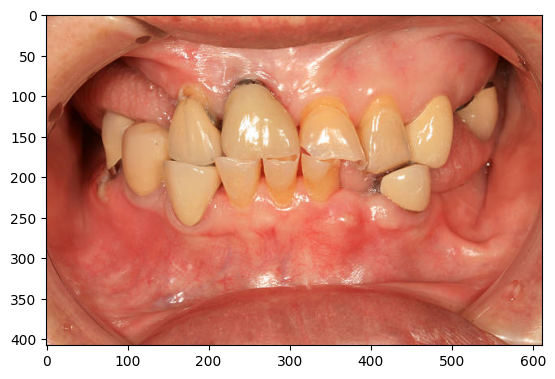

In [14]:
from PIL import Image
import matplotlib.pyplot as plt
cariesimg=Image.open("/kaggle/working/oral-diseases/calculus/(100).jpg")
plt.imshow(cariesimg)

#### Sample of gingivitis


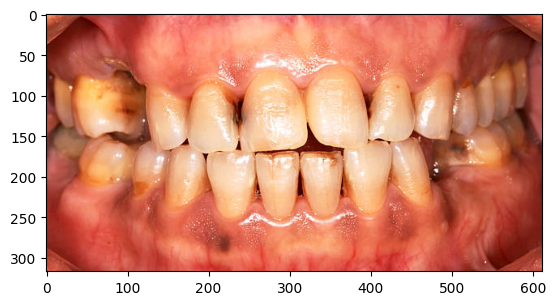

In [15]:
gingivitisimg=Image.open("/kaggle/working/oral-diseases/gingivitis/(69).jpg")
plt.imshow(gingivitisimg)

#### Sample of tooth discoloration


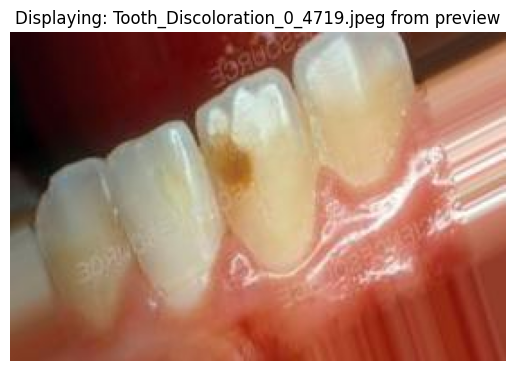

In [16]:
import os
from PIL import Image
import matplotlib.pyplot as plt

toothDiscoloration_dir = "/kaggle/working/oral-diseases/toothDiscoloration"

found_image = False
for root, _, files in os.walk(toothDiscoloration_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
            image_path = os.path.join(root, file)
            try:
                toothDiscolorationimg = Image.open(image_path)
                plt.imshow(toothDiscolorationimg)
                plt.title(f"Displaying: {file} from {root.split('/')[-1]}")
                plt.axis('off') # Hide axes for cleaner image display
                plt.show()
                found_image = True
                break # Display only one image and exit
            except Exception as e:
                print(f"Error opening image {file}: {e}")
    if found_image:
        break

if not found_image:
    print(f"No image files found in {toothDiscoloration_dir} or its subdirectories.")

#### Sample of mouth ulcers

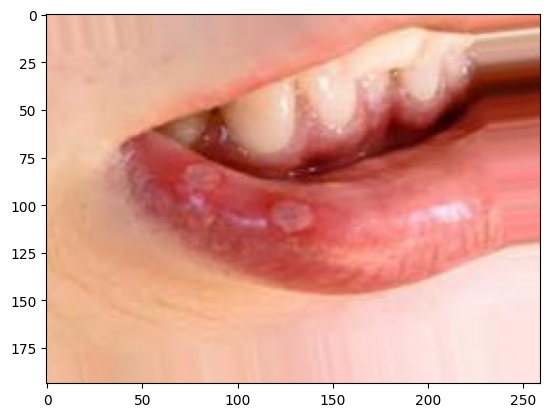

In [17]:
ulcersimg=Image.open("/kaggle/working/oral-diseases/ulcers/Mouth_Ulcer_0_5.jpeg")
plt.imshow(ulcersimg)

#### Sample of hypodontia

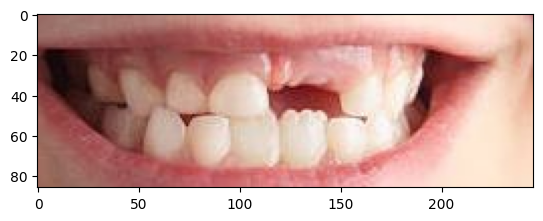

In [18]:
hypodontiaimg=Image.open("/kaggle/working/oral-diseases/hypodontia/(20).JPG")
plt.imshow(hypodontiaimg)

#### Sample of calculus

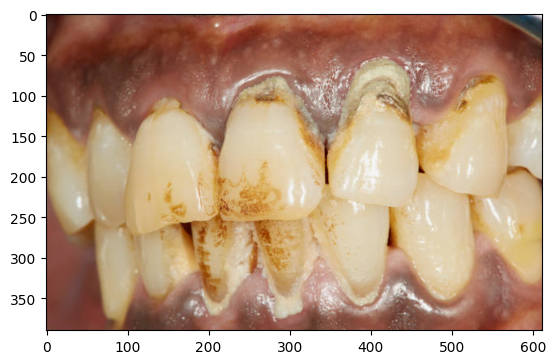

In [19]:
calculusimg=Image.open("/kaggle/working/oral-diseases/calculus/(80).jpg")
plt.imshow(calculusimg)

## Visualizations

<BarContainer object of 6 artists>

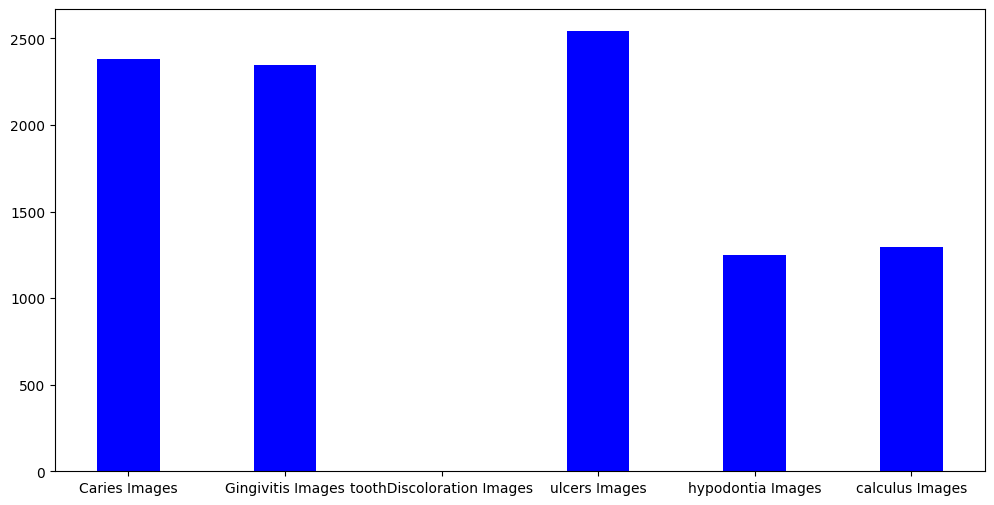

In [20]:
# Bar chart ofclsasses
fig = plt.figure(figsize = (12, 6))
plt.bar(['Caries Images', 'Gingivitis Images', 'toothDiscoloration Images', 'ulcers Images', 'hypodontia Images', 'calculus Images'],
        [len(os.listdir(caries_dir)), len(os.listdir(gingivitis_dir)),
                   len(os.listdir(toothDiscoloration_dir)), len(os.listdir(ulcers_dir)),
                    len(os.listdir(hypodontia_dir)), len(os.listdir(calculus_dir))], color ='blue', width = 0.4)

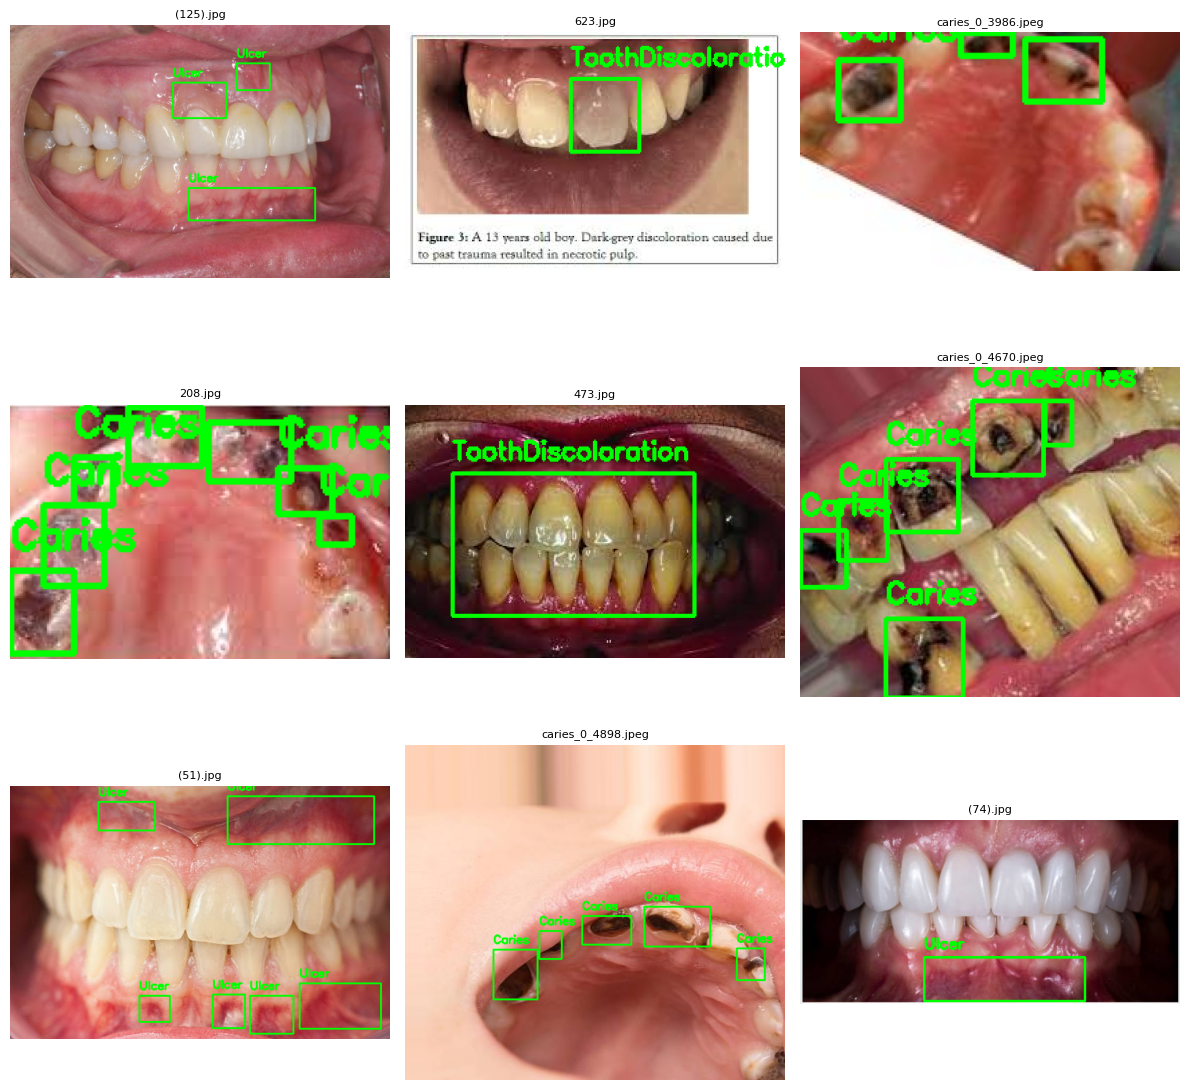

In [21]:
classes = ['Caries', 'Gingivitus', 'ToothDiscoloration', 'Ulcer']

image_path = img_train
label_path = label_train

image_files = [f for f in os.listdir(image_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
num_images = 9

plt.figure(figsize=(12, 12))

for i, img_name in enumerate(image_files[:num_images]):
    img_full_path = os.path.join(image_path, img_name)
    img = cv2.imread(img_full_path)

    if img is None:
        continue

    h, w, _ = img.shape

    label_file = os.path.splitext(img_name)[0] + '.txt'
    label_full_path = os.path.join(label_path, label_file)

    if os.path.exists(label_full_path):
        with open(label_full_path, 'r') as f:
            for line in f.readlines():
                cls, x, y, bw, bh = map(float, line.split())

                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)

                cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
                cv2.putText(img, classes[int(cls)], (x1, y1-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    plt.subplot(3, 3, i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(img_name, fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Data Cleaning

In [22]:
clean_dir = "/kaggle/working/clean-dataset"
os.makedirs(clean_dir, exist_ok=True)

exclude_folders = [
    "Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset"
]

image_ext = (".jpg", ".jpeg", ".png", ".gif")

for class_name in os.listdir(build_dir):
    class_path = os.path.join(build_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    if class_name in exclude_folders:
        print(f"Skip {class_name}")
        continue

    output_class_dir = os.path.join(clean_dir, class_name)
    os.makedirs(output_class_dir, exist_ok=True)

    for root, dirs, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith(image_ext):
                src = os.path.join(root, file)
                dst = os.path.join(output_class_dir, file)

                if os.path.exists(dst):
                    name, ext = os.path.splitext(file)
                    dst = os.path.join(output_class_dir, f"{name}_dup{ext}")

                shutil.copy(src, dst)

    count = len(os.listdir(output_class_dir))
    print(f" {class_name}: {count} images")

print(clean_dir)

 caries: 2382 images
 toothDiscoloration: 2017 images
 hypodontia: 1251 images
 ulcers: 2541 images
 calculus: 1296 images
 gingivitis: 2349 images
/kaggle/working/clean-dataset


## Duplicate handling

In [23]:
CALCULUS_DIR = os.path.join(clean_dir, "calculus")
GINGIVITIS_DIR = os.path.join(clean_dir, "gingivitis")

PHASH_THRESHOLD = 6  # 6 bits dif → near-dup

def compute_phash(image_path):
    try:
        img = Image.open(image_path).convert("RGB")
        return imagehash.phash(img)
    except:
        return None

calculus_hashes = {}
gingivitis_hashes = {}

# Hash Calculus images
for img_name in tqdm(os.listdir(CALCULUS_DIR)):
    path = os.path.join(CALCULUS_DIR, img_name)
    h = compute_phash(path)
    if h is not None:
        calculus_hashes[img_name] = h

# Hash Gingivitis images
for img_name in tqdm(os.listdir(GINGIVITIS_DIR)):
    path = os.path.join(GINGIVITIS_DIR, img_name)
    h = compute_phash(path)
    if h is not None:
        gingivitis_hashes[img_name] = h

to_remove_g = []
to_remove_c = []

for g_name, g_hash in tqdm(gingivitis_hashes.items()):
    for c_name, c_hash in calculus_hashes.items():
        if g_hash - c_hash <= PHASH_THRESHOLD:
            to_remove_g.append(g_name)
            break


100%|██████████| 2349/2349 [00:06<00:00, 352.75it/s]


## Remove duplicates

In [24]:
for img in to_remove_g:
    path = os.path.join(GINGIVITIS_DIR, img)
    if os.path.exists(path):
        os.remove(path)

print("\nDe-duplication complete")
print(f" Removed from Gingivitis: {len(to_remove_g)}")
print(f"Removed from Calculus:   {len(to_remove_c)}")
print(f" Total removed: {len(to_remove_g) + len(to_remove_c)}")


De-duplication complete
 Removed from Gingivitis: 749
Removed from Calculus:   0
 Total removed: 749


# Data spitting 

# Data balancing


## Copy all original clean data first

In [28]:
balanced_dir = "/kaggle/working/balanced-dataset"
os.makedirs(balanced_dir, exist_ok=True)

for class_name in os.listdir(clean_dir):
    src_class = os.path.join(clean_dir, class_name)
    dst_class = os.path.join(balanced_dir, class_name)
    os.makedirs(dst_class, exist_ok=True)

    for img in os.listdir(src_class):
        shutil.copy(
            os.path.join(src_class, img),
            os.path.join(dst_class, img)
        )

## Data augmanting on the target

In [29]:
augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0))
])

def augment_to_target(class_name, target_count):
    class_path = os.path.join(balanced_dir, class_name)
    images = os.listdir(class_path)
    current_count = len(images)

    if current_count >= target_count:
        print(f" {class_name} already has {current_count} images. Skipping.")
        return

    idx = 0
    while current_count < target_count:
        img_name = random.choice(images)
        img_path = os.path.join(class_path, img_name)

        img = Image.open(img_path).convert("RGB")
        aug_img = augment_transform(img)

        new_name = f"aug_{idx}_{img_name}"
        aug_img.save(os.path.join(class_path, new_name))

        idx += 1
        current_count += 1

    print(f" {class_name} augmented to {target_count} images")


augment_to_target("hypodontia", 2500)
augment_to_target("calculus", 2500)
augment_to_target("gingivitis", 2500)


 hypodontia augmented to 2500 images
 calculus augmented to 2500 images
 gingivitis augmented to 2500 images


# Model

## EfficientNetB0

### LOAD THE DATASET tenor utility

In [ ]:
data_dir = "/kaggle/working/balanced-dataset"
img_size = (224, 224)
batch_size = 16
seed = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

val_batches = tf.data.experimental.cardinality(temp_ds).numpy() // 2
val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

### Optimize Dataset Performance

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

### EfficientNetB0 Base ModelA

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

### classinfier head

In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

### Compile the Model

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

### Callbacks

In [ ]:
cb = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    ),

    callbacks.ModelCheckpoint(
        "best_efficientnetb0_oral.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

### Feature Extraction first train

In [ ]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=cb
)

### Unfreeze

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

### SEcond compile after unfreezing

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Second Train (Fine-Tuning)

In [ ]:
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=cb
)

### Combine Training History

In [ ]:
acc = history1.history["accuracy"] + history2.history["accuracy"]
val_acc = history1.history["val_accuracy"] + history2.history["val_accuracy"]

loss = history1.history["loss"] + history2.history["loss"]
val_loss = history1.history["val_loss"] + history2.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

### Evaluate on Test Dataset


In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

print(f"\nTest Accuracy: {test_acc:.2%}")

### Plot & CLassifecation report

In [ ]:
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Val Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Val Loss")
plt.legend()
plt.title("Training and Validation Loss")

plt.show()
#########
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()
######################
print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

### Generate Predictions

In [ ]:
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

y_pred_probs = model.predict(test_ds)

y_pred = np.argmax(y_pred_probs, axis=1)

### SAVE EFFICIENTNET MODEL

In [ ]:
model.save("efficientnet_oral.keras")
import json
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("saved")


# prediction

In [ ]:

def predict_image(model, img_path, img_size=(224, 224), class_names=None):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Add batch dimension
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

    # Make predictions
    predictions = model.predict(img_array)
    predicted_class_idx = np.argmax(predictions, axis=1)[0]
    predicted_class = class_names[predicted_class_idx]
    predicted_confidence = np.max(predictions)

    # Display the image and prediction result
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class} ({predicted_confidence*100:.2f}%)")
    plt.show()

    return predicted_class, predicted_confidence

# Example usage:
img_path = '/kaggle/input/datasets/marwanammar/mymouse/processed_image.png'  # Replace with the path to the image you want to predict
predicted_class, predicted_confidence = predict_image(model, img_path, img_size=img_size, class_names=class_names)

print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {predicted_confidence*100:.2f}%")

# YoloV8

In [31]:
src = "/kaggle/input/datasets/salmansajid05/oral-diseases/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Data/data.yaml"
dst = "/kaggle/working/data.yaml"

shutil.copy(src, dst)

yaml_text = """
path: /kaggle/input/datasets/salmansajid05/oral-diseases/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Data

train: images/train
val: images/val

nc: 4
names: ['Caries','Ulcer','Tooth Discoloration','Gingivitis']
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_text)



## Train the model

In [33]:
model = YOLO('yolov8n.pt')

model.train(
    data="/kaggle/working/data.yaml",
    epochs=10,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    flipud=0.5,
    fliplr=0.5
)

Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e1cbbd38d70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
print("\nStarting YOLO Training...")
model = YOLO("yolov8n.pt")   
model.train(
    data=f"{YOLO_DIR}/data.yaml",
    epochs=5,
    imgsz=416,
    batch=8,
    project="runs/detect",
    name="caries_final"
)

print("Training completed!")


In [35]:
import glob
runs = sorted(glob.glob("/kaggle/working/runs/detect/train*"))
latest_run = runs[-1]

best_model_path = latest_run + "/weights/best.pt"

print("Using:", best_model_path)

model = YOLO(best_model_path)
model.val(data="/kaggle/working/data.yaml")

Using: /kaggle/working/runs/detect/train-2/weights/best.pt
Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.3 ms, read: 41.5±28.7 MB/s, size: 21.6 KB)
val: Scanning /kaggle/input/datasets/salmansajid05/oral-diseases/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Data/labels/val... 43 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 49/49 823.5it/s 0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/salmansajid05/oral-diseases/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Data/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.3it/s 1.2s0.5s
               

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e1cbadce4b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

# Model Mterics

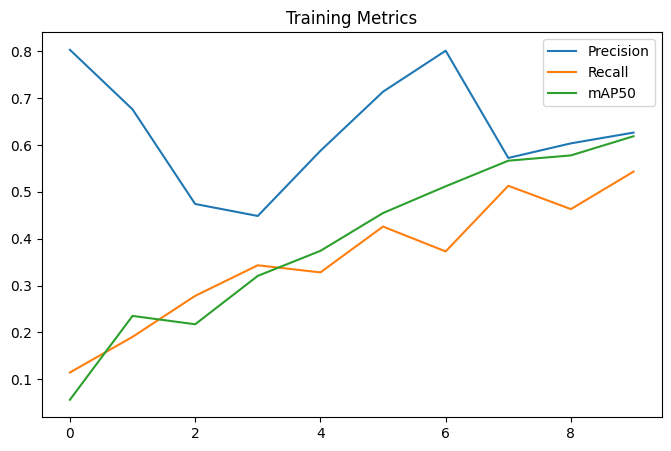

In [36]:
res=latest_run + "/results.csv"
df = pd.read_csv(res)
plt.figure(figsize=(8,5))
plt.plot(df["metrics/precision(B)"], label="Precision")
plt.plot(df["metrics/recall(B)"], label="Recall")
plt.plot(df["metrics/mAP50(B)"], label="mAP50")

plt.legend()
plt.title("Training Metrics")
plt.show()

## model.predict

In [37]:
model.predict(
    source="/kaggle/input/datasets/salmansajid05/oral-diseases/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Data/images/val",
    conf=0.25,
    save=True
)


image 1/49 /kaggle/input/datasets/salmansajid05/oral-diseases/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Data/images/val/(225).jpg: 320x640 (no detections), 38.8ms
image 2/49 /kaggle/input/datasets/salmansajid05/oral-diseases/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Data/images/val/(226).jpg: 416x640 7 Gingivitiss, 38.5ms
image 3/49 /kaggle/input/datasets/salmansajid05/oral-diseases/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Data/images/val/(227).jpg: 448x640 (no detections), 40.1ms
image 4/49 /kaggle/input/datasets/salmansajid05/oral-diseases/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Data/images/val/(228).jpg: 448x640 (no detection

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Caries', 1: 'Ulcer', 2: 'Tooth Discoloration', 3: 'Gingivitis'}
 obb: None
 orig_img: array([[[238, 240, 234],
         [241, 242, 238],
         [147, 148, 146],
         ...,
         [255, 252, 254],
         [242, 239, 241],
         [226, 224, 224]],
 
        [[242, 244, 238],
         [210, 211, 207],
         [ 32,  33,  31],
         ...,
         [228, 225, 227],
         [242, 239, 241],
         [233, 231, 231]],
 
        [[251, 252, 248],
         [227, 228, 224],
         [  4,   5,   3],
         ...,
         [236, 233, 235],
         [246, 243, 245],
         [238, 236, 236]],
 
        ...,
 
        [[236, 237, 235],
         [223, 224, 222],
         [ 43,  43,  43],
         ...,
         [216, 219, 224],
         [227, 226, 228],
         [237, 237, 237]],
 
        [[231, 231, 231],
         [255, 255, 255],
   

Using: /kaggle/working/runs/detect/predict


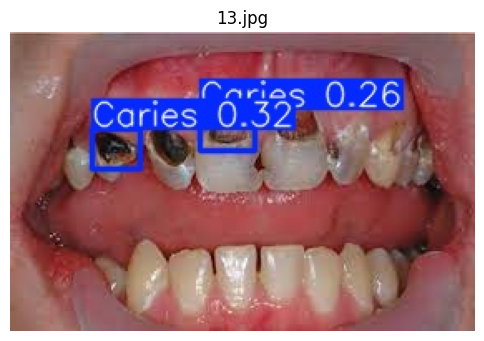

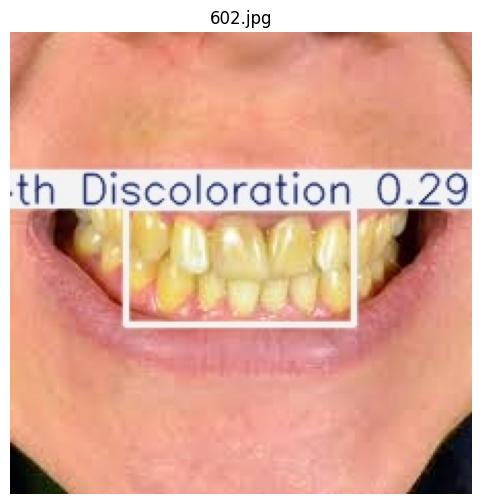

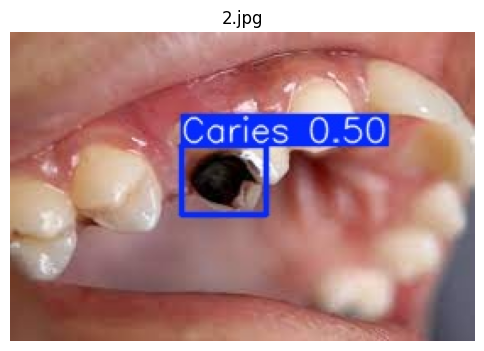

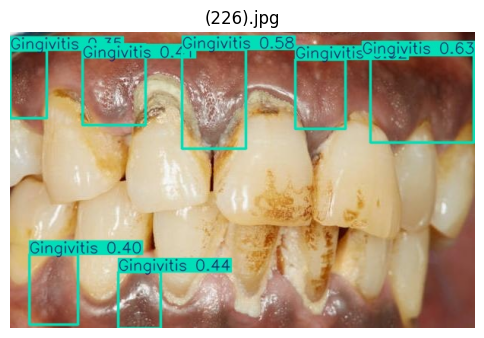

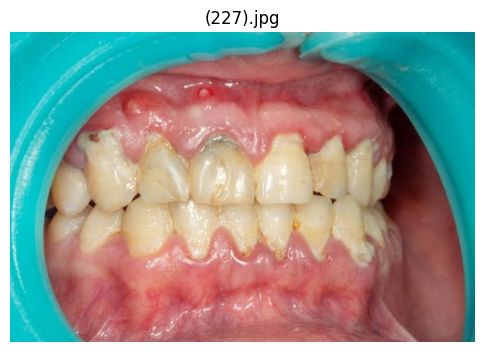

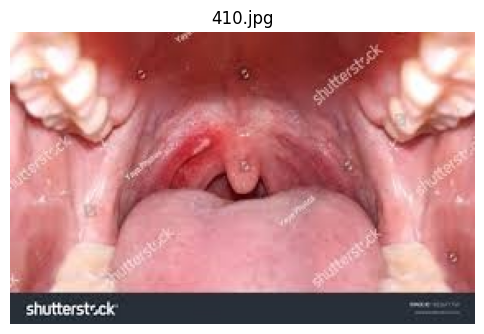

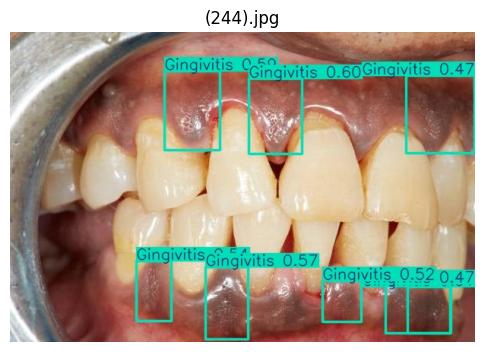

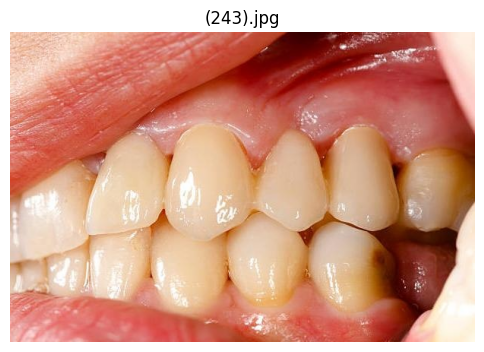

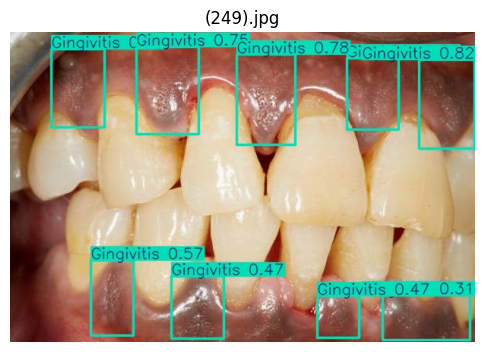

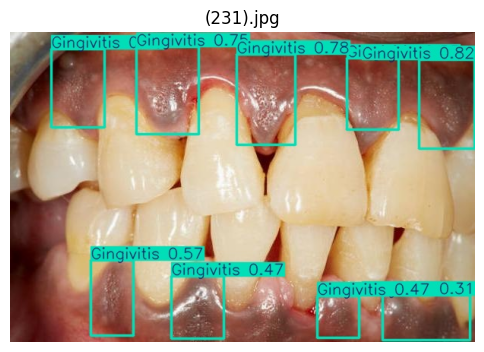

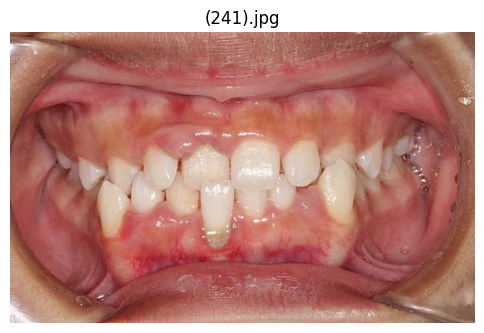

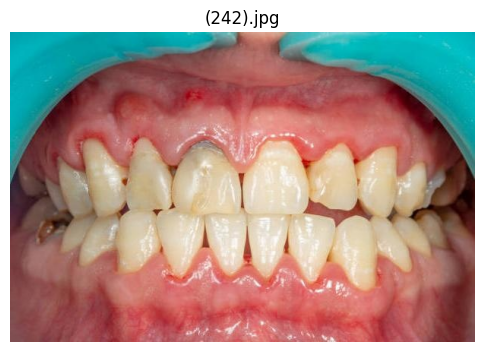

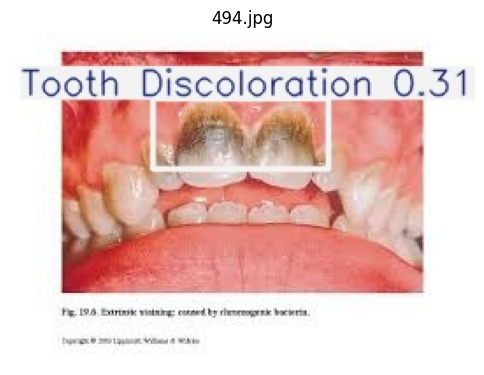

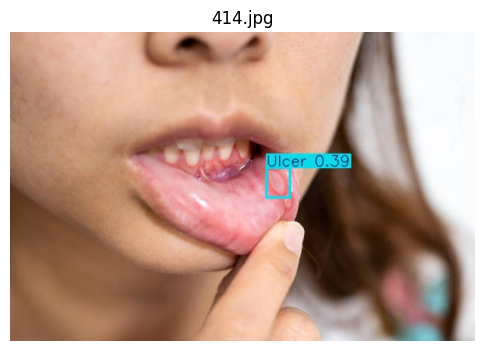

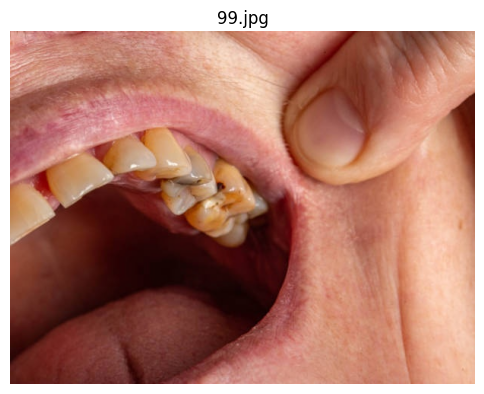

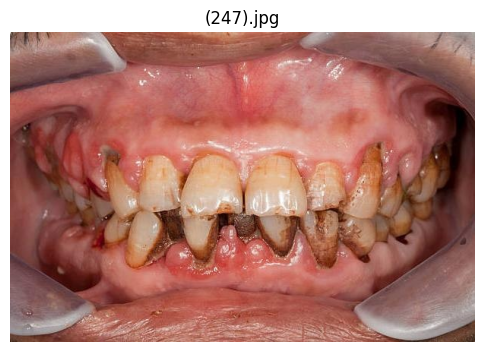

In [39]:
pred_dir = "/kaggle/working/runs/detect/"

folders = sorted(glob.glob(pred_dir + "predict*"))
latest_folder = folders[-1]

print("Using:", latest_folder)

images = glob.glob(latest_folder + "/*.jpg") + glob.glob(latest_folder + "/*.png")

for img_path in images[:16]:
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title(img_path.split("/")[-1])
    plt.axis("off")
    plt.show()